In [31]:
# packages
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from sklearn.model_selection import train_test_split 
from sklearn.metrics import mean_squared_error as mse
from ISLP.models import (ModelSpec as MS, summarize)

# set seed
seed = 4721

In [32]:
Housing = pd.read_csv('data/Housing.csv')
Housing.dtypes

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

In [33]:
#setting yes or no variables as 1 or 0
binary_vars = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']
for var in binary_vars:
    Housing[var] = (Housing[var] == 'yes').astype(int)

#make furnishingstatus into dummy variables
Housing = pd.get_dummies(Housing, columns=['furnishingstatus'], drop_first=True)
Housing['furnishingstatus_semi-furnished'] = Housing['furnishingstatus_semi-furnished'].astype(int)
Housing['furnishingstatus_unfurnished'] = Housing['furnishingstatus_unfurnished'].astype(int)
Housing.dtypes

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished    int64
furnishingstatus_unfurnished       int64
dtype: object

In [20]:
indep_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
              'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
              'parking', 'prefarea', 'furnishingstatus_semi-furnished',
              'furnishingstatus_unfurnished']

X = Housing[indep_vars]
y = Housing['price']

In [21]:
X_train, X_test, y_train, y_test, Train, Test = train_test_split(X, y, Housing,
                                                                 random_state=seed,
                                                                 test_size=0.25,
                                                                 shuffle=True)

In [22]:
Housing.describe()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.416514,0.326606
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.493434,0.469402
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


In [29]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

model_1 = sm.OLS(y_train, X_train_sm)
results_1 = model_1.fit()
summarize(results_1)

,coef,std err,t,P>|t|
const,44700.0000,287000.000,0.156,0.876
area,244.3151,26.408,9.252,0.000
bedrooms,116500.0000,76300.000,1.527,0.128
bathrooms,999800.0000,117000.000,8.511,0.000
stories,444000.0000,70500.000,6.301,0.000
mainroad,440900.0000,152000.000,2.907,0.004
guestroom,544100.0000,152000.000,3.576,0.000
basement,267500.0000,124000.000,2.164,0.031
hotwaterheating,756500.0000,234000.000,3.227,0.001
airconditioning,818700.0000,119000.000,6.887,0.000


In [24]:
#R^2
print("R^2: ", results_1.rsquared)

#MSE on Train and Test data
preds_train = results_1.predict(X_train_sm)
preds_test = results_1.predict(X_test_sm)

mse_train = mse(y_train, preds_train)
mse_test = mse(y_test, preds_test)

print("MSE Train:", mse_train)
print("MSE Test:", mse_test)
print("RMSE Test:", np.sqrt(mse_test))

R^2:  0.7012809213540749
MSE Train: 974427529853.2482
MSE Test: 1569160187650.1423
RMSE Test: 1252661.242176089


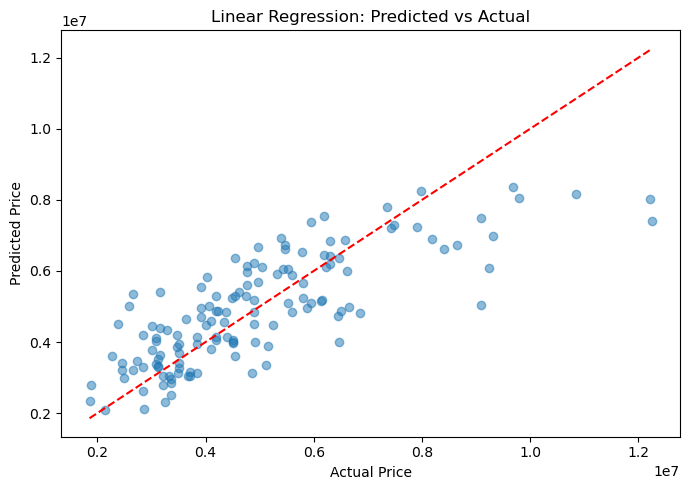

In [25]:
fig, ax = subplots(figsize=(7, 5))
ax.scatter(y_test, preds_test, alpha=0.5)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax.set_xlabel('Actual Price')
ax.set_ylabel('Predicted Price')
ax.set_title('Linear Regression: Predicted vs Actual')
plt.tight_layout()
plt.show()

In [26]:
print(Housing['price'].describe())

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64
